# Kaggle Chat Assistant using Retrieval Augmented Generation (RAG)

# Introduction

## Objective of our Project

The objective of the project is to develop a chat assistant for Common questions about the Kaggle platform using RAG (Retrieval Augmented Generation) in combination with Gemma LLM. This involves leveraging RAG's capabilities to retrieve relevant information from KAGGLE support documents and augmenting Gemma LLM's responses with this information. Ultimately, the aim is to create an intelligent chat assistant that can provide accurate and contextually relevant answers to user queries regarding KAGGLE platform functionalities and frequently asked questions.


## Understanding RAG: Retrieval Augmented Generation

RAG, or Retrieval Augmented Generation, is an approach aimed at enhancing the capabilities of language models. The primary objective of RAG is to enable the seamless integration of information retrieval and generation tasks within a Language Model(LM).

Let's delve into its components:

* Retrieval: This initial phase involves seeking out important information in response to a given query. For instance, if the query is "What are Kaggle Competitions?" RAG would scan through sources provides and extract relevant passages.

* Augmented: Once the relevant information is gathered, the next step is to enrich the input provided to the Language Model with this retrieved data. Essentially, it enhances the LM's understanding by incorporating contextually significant details obtained through retrieval.

* Generation: The final stage involves leveraging the retrieved information and the augmented input to produce generative outputs. This task is completed by the Language Model, which utilizes all the input data to generate comprehensive and contextually appropriate responses.

In essence, RAG combines information retrieval and generation processes to empower Language Models to produce more informed and contextually relevant outputs.



## Benefits of using RAG

RAG serves an important purpose in making Language Models (LLMs) better. Here's why RAG is helpful:

* Preventing Making Things Up (Hallucinations): LLMs are really good at making text that sounds good, but it's not always true. RAG helps make sure that what the LLM writes is based on real information from relevant sources. This means the text it generates isn't just nice-sounding, it's also accurate.

* Using Your Own Information: Regular LLMs learn from a lot of stuff on the internet, so sometimes their answers can be kind of generic. RAG fixes this by letting you use your own documents to teach the LLM. For example, it can learn from your company's customer support guides. This makes sure that the answers it gives are more specific and helpful to you.

## We are going to complete this in 8 Steps:

1. Importing necessary Libraries.
2. We'll then start by importing the PDF document which contains information about Kaggle platform. I have referred the Kaggle Docs page to create this document. For reference visit https://www.kaggle.com/docs/ .
3. Prepare the text extracted from the PDF documents to ensure it is formatted appropriately for integration with an embedding model.
4. We will create chunks of sentences in order to have small segments of texts.
5. Transform each segment of the text into numerical representations, known as embeddings, which can be stored for future reference.
6. Develop a retrieval system capable of utilizing vector search algorithms to identify relevant sections of text based on user queries.
7. Defining our Gemma LLM model for text generation
8. Construct a prompt that integrates the retrieved text segments, enhancing the context for subsequent processing and Utilize Gemma Language Model (LLM) to generate responses to user queries by leveraging the information contained within the PDF docs.

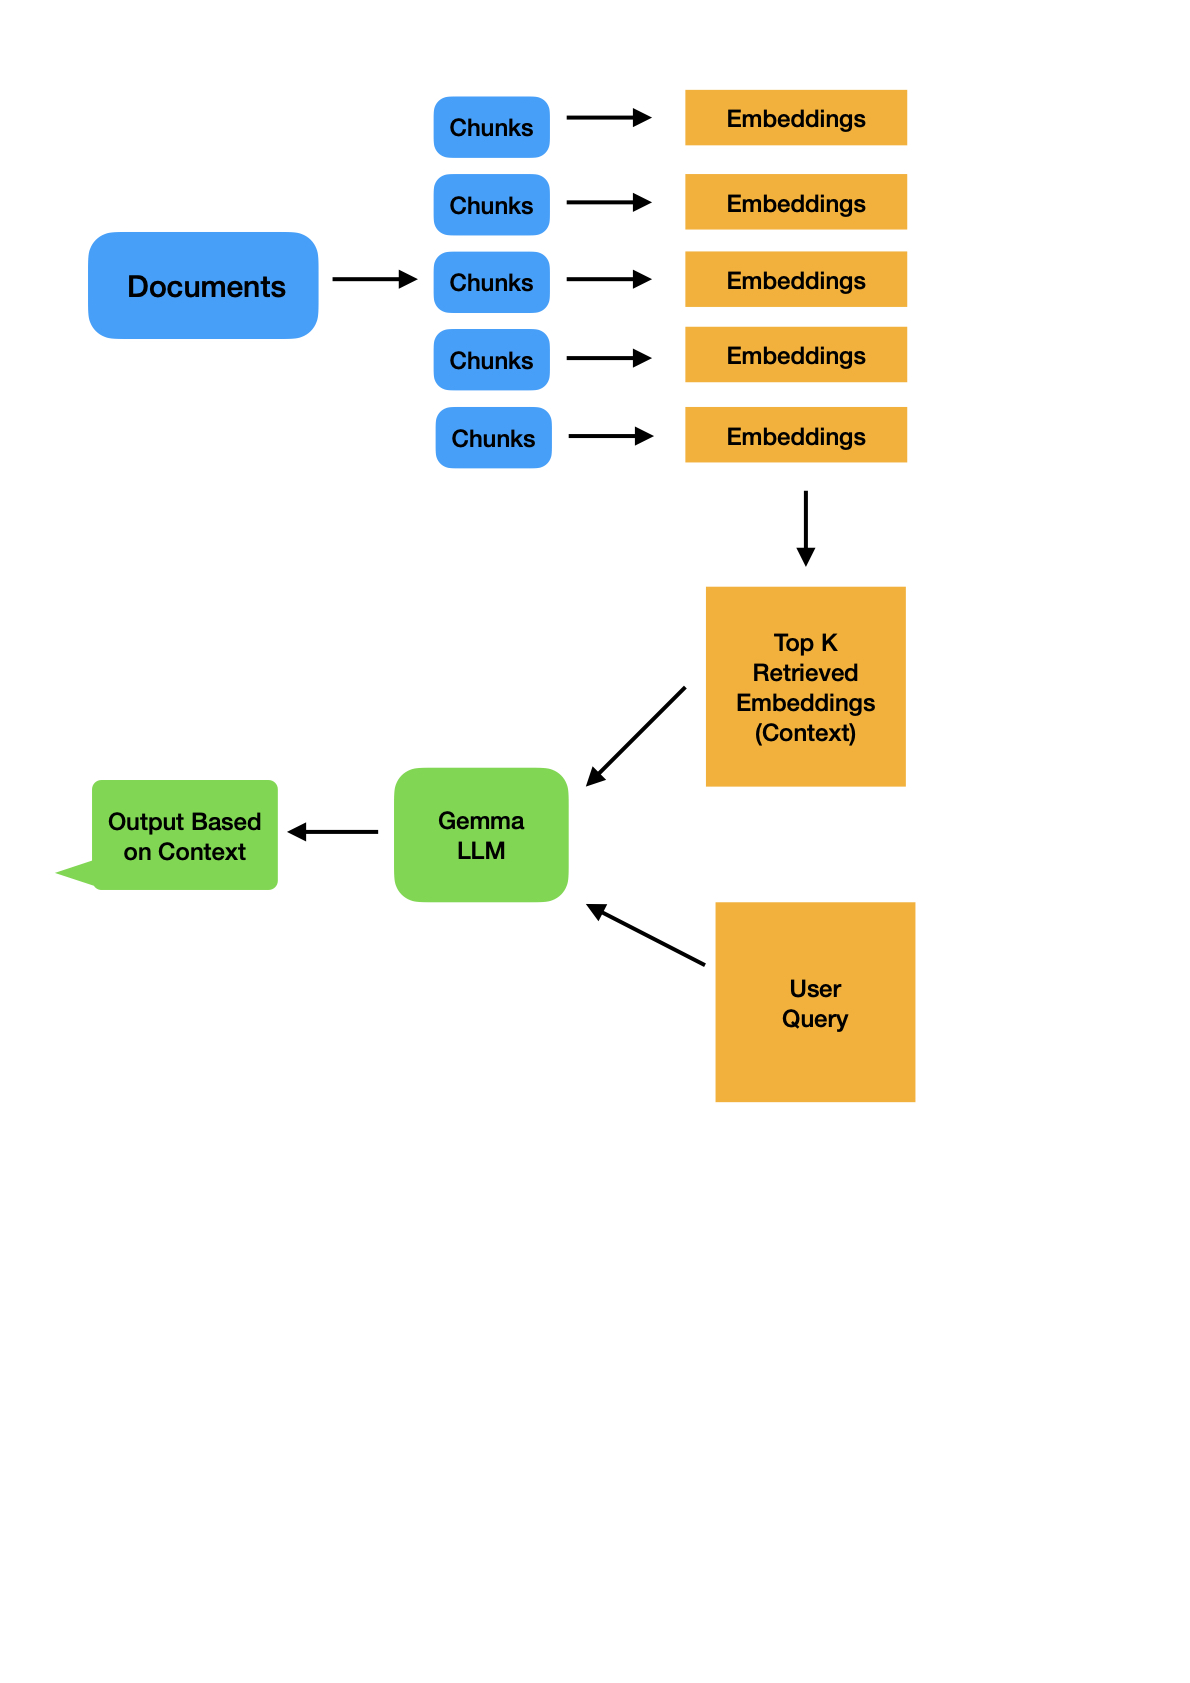

### Download necessary Libraries

In [1]:
!pip install -q -U PyMuPDF
!pip install -q -U transformers=="4.38.2"
!pip install -q accelerate
!pip install -q -i https://pypi.org/simple/ bitsandbytes
!pip install -q -U sentence_transformers

# 1. Importing Libraries

In [2]:
import os
import re
import fitz 
import random
import pandas as pd
import numpy as np
import torch
import spacy
from spacy.lang.en import English


from sentence_transformers import util,SentenceTransformer
from transformers import AutoTokenizer, AutoModelForCausalLM
from transformers.utils import is_flash_attn_2_available 
from transformers import BitsAndBytesConfig

# 2. Importing Document, Extracting text and useful statistics out of data

* The function **Read_pdf** opens the Kaggle_User_doc PDF file and reads the text content from each page. It will collect various statistics about each page's text, such as character count, word count, sentence count, and estimated token count. Finally, it returns **pages_texts** which is a list of dictionaries, each containing information about a single page's text content and its associated statistics.


In [3]:
def Read_pdf(pdf_path):
    doc = fitz.open(pdf_path)
    pages_texts = []
    
    #Add a sentencizer pipeline (spacy) to get the count of sentences
    nlp = English()
    nlp.add_pipe('sentencizer')

    for page_number, page in enumerate(doc):
        text = page.get_text()
        text = text.replace("\n"," ").strip()
        pages_texts.append({"page_number": page_number+1,
                            "page_char_count": len(text),
                            "page_word_count": len(text.split(" ")),
                            "page_sentence_count_row": len(list(nlp(text).sents)),
                            "page_token_count": len(text)/4,
                            "text": text,
                            "sentences": list(nlp(text).sents)
                            })
     
    
    return pages_texts

In [4]:
## Now we pass are document into the function and analyse it

#Extracting data from our document
pages_texts = Read_pdf('/kaggle/input/kaggle-guide/Kaggle_User_doc.pdf')

#Converting extracted data into a pandas dataframe to analyse
pages_texts_df = pd.DataFrame(pages_texts)

pages_texts_df.head()

,page_number,page_char_count,page_word_count,page_sentence_count_row,page_token_count,text,sentences
0,1,1311,215,7,327.75,How to Use Kaggle Competitions Find challeng...,"[(How, to, Use, Kaggle, , Competitions, , Fi..."
1,2,2476,414,17,619.00,Research Research competitions are another co...,"[(Research, , Research, competitions, are, an..."
2,3,1983,336,15,495.75,Playground Playground competitions are a “for...,"[(Playground, , Playground, competitions, are..."
3,4,2344,400,27,586.00,Code Competitions Some competitions are code ...,"[(Code, Competitions, , Some, competitions, a..."
4,5,1665,290,14,416.25,What are the compute limits of Notebooks? The...,"[(What, are, the, compute, limits, of, Noteboo..."


In [5]:
#Checking the average counts
pages_texts_df.describe()

,page_number,page_char_count,page_word_count,page_sentence_count_row,page_token_count
count,85.000000,85.000000,85.000000,85.000000,85.000000
mean,43.000000,1772.658824,312.741176,14.164706,443.164706
std,24.681302,552.340336,98.053090,6.337430,138.085084
min,1.000000,21.000000,5.000000,1.000000,5.250000
25%,22.000000,1434.000000,265.000000,10.000000,358.500000
50%,43.000000,1808.000000,324.000000,14.000000,452.000000
75%,64.000000,2210.000000,394.000000,18.000000,552.500000
max,85.000000,2942.000000,512.000000,34.000000,735.500000


#  3. Chunking the sentences

Text splitting or chunking refers to the process of dividing longer pieces of text into smaller segments. In this context, we aim to break down text into shorter units, typically consisting of predefined number of sentences.

Benefits of Chunking

* Text Filtering: By breaking text into smaller groups, it becomes easier to filter and analyze. Smaller text segments are more manageable compared to large passages of text.

* Compatibility with Embedding Models: Text chunks need to fit within the context window of embedding models, often limited to a certain number of tokens (e.g., 384 tokens for Sentence Transformer). Splitting text ensures that each segment remains within the model's processing capabilities.

* Specific and Focused Contexts: Text splitting enables us to create more specific and focused contexts for Language Models (LLMs). This allows LLMs to process and understand text in a more targeted manner, potentially leading to more accurate and relevant outputs.


In the function **split_into_chunks** we will pass our list of dictionaries and divide the sentences into given number of slice_size and return back the list. We will also overlap some informations between chunks to get better results. 

In [6]:
def split_into_chunks(slice_size,sentences):
    li = [sentences[i:i+slice_size] for i in range(0,len(sentences),2)]     
    return li

In [7]:
slice_size = 5

#Adding the element chunks and number of chunks in our list of dictionaries
for item in pages_texts:
    item['chunks'] = split_into_chunks(slice_size,item['sentences'])
    item['no_of_chunks'] = len(item['chunks'])

In [8]:
pages_texts[1]['chunks'][0]

[Research  Research competitions are another common type of competition on Kaggle.,
 Research competitions  feature problems which are more experimental than featured competition problems.,
 For example,  some past research competitions have included:  •  Google Landmark Retrieval Challenge - Given an image, can you find all the same landmarks in  a dataset?,
  •  Right Whale Recognition - Identify endangered right whales in aerial photographs  •  Large Scale Hierarchical Text Classification - Classify Wikipedia documents into one of  ~300,000 categories  Research competitions do not usually offer prizes or points due to their experimental nature.,
 But they  offer an opportunity to work on problems which may not have a clean or easy solution and which are  integral to a specific domain or area in a slightly less competitive environment.]

# 4. Creating Individual Representations for Each Chunk

Now our objective is to generate a distinct numerical representation for every chunk of sentences. This approach provides us with a high level of granularity, allowing us to delve deeply into the specifics of each text segment utilized in our model. By doing so, we can precisely analyze and understand the characteristics of each chunk, facilitating a more nuanced exploration of the text data.

In [9]:
text_chunks = []

for item in pages_texts:
    for sen_chunk in item['chunks']:
        chunk_dict = {}
        chunk_dict['page_number'] = item['page_number']

        #we will join the sentences in one chunk together as a paragraph
        joined_sen = "".join(str(sen_chunk)).strip()
        joined_sen = re.sub(r'^\[|\]$', '', joined_sen)
        joined_sen = re.sub(r'^\s*[\*\-\•]\s*', '', joined_sen, flags=re.MULTILINE)
        joined_sen = re.sub(r'\s{2,}', ' ', joined_sen)
        chunk_dict['text'] = joined_sen

        #Get stat on chunks
        chunk_dict['chunk_char_count'] = len(joined_sen)
        chunk_dict['chunk_word_count'] = len([word for word in joined_sen.split(" ")])
        chunk_dict['chunk_token_count'] = len(joined_sen) / 4 

        text_chunks.append(chunk_dict)
        
print(f"Length of text chunks: {len(text_chunks)}")

Length of text chunks: 624


In [10]:
#randomly sampling one record
random.sample(text_chunks,k=1)

[{'page_number': 4,
  'text': 'And the winning models tend to be far simpler than the winning models in other competitions, as they must be made to run within the compute constraints imposed by the platform., Code competitions are configured with their own unique constraints on the Notebooks you can submit., These may be restricted by characteristics like: CPU or GPU runtime, ability to use external data, and access to the internet., To learn the constraints you must adhere to, review the Requirements for that specific competition., An example of a code competition is Quora Insincere Questions Classification.',
  'chunk_char_count': 585,
  'chunk_word_count': 93,
  'chunk_token_count': 146.25}]

In [11]:
text_chunks_df = pd.DataFrame(text_chunks)
text_chunks_df.describe()

,page_number,chunk_char_count,chunk_word_count,chunk_token_count
count,624.000000,624.000000,624.000000,624.000000
mean,42.625000,528.626603,84.955128,132.156651
std,25.691035,238.038304,38.547687,59.509576
min,1.000000,8.000000,1.000000,2.000000
25%,20.000000,388.500000,61.000000,97.125000
50%,40.000000,529.500000,85.000000,132.375000
75%,68.000000,658.250000,107.000000,164.562500
max,85.000000,1627.000000,265.000000,406.750000


We can see here the average chunk token count is 216 which is good because the maximum input token count for the embedding model we will be using is 384. Also we can see that the minimum token count is approximately 6 which is quite low. So we will remove chunks which have token count less than 30.

In [12]:
text_chunks_filtered = text_chunks_df[text_chunks_df['chunk_token_count']>30].to_dict(orient='records')
print(f"Number of chunks after filtering: {len(text_chunks_filtered)}")

Number of chunks after filtering: 604


# 5. Embedding our Text chunks  

Embedding is the conversion of words or text into numerical vectors. These vectors capture semantic relationships, enabling machine learning models to understand and process language. Each word or text segment is represented by a fixed-length vector, facilitating tasks like text classification, sentiment analysis, and language translation in computational applications. 

Below are the tasks:
1. Convert text chunks into Embeddings.
2. Take all the embeddings stack them and convert them to torch tensor.

In [13]:
# Defining the embedding model
embedding_model = SentenceTransformer(model_name_or_path = 'all-mpnet-base-v2', device ='cuda')

# Using GPU to compute embeddings
embedding_model.to('cuda')    

for item in text_chunks_filtered:
    item['embedding'] = embedding_model.encode(item['text'],show_progress_bar = False)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

1_Pooling/config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [14]:
#randomly sampling one record
random.sample(text_chunks_filtered,k=1)

[{'page_number': 33,
  'text': 'This is a collection consisting of a Notebook version, the output it generates, and the associated metadata about the environment., In the Script editor, the code you write is executed all at once, whenever you generate a new version., For finer-grained control, it’s also possible to specifically execute only a single line or selection of lines of code., Notebooks are built on Jupyter notebooks., Notebook Notebooks consist of individual cells, each of which may be a Markdown (text) cell or a code cell.',
  'chunk_char_count': 507,
  'chunk_word_count': 83,
  'chunk_token_count': 126.75,
  'embedding': array([ 1.14471251e-02, -6.62401095e-02, -7.46741006e-03, -3.28165852e-02,
         -5.08065633e-02,  3.35483924e-02,  5.52475527e-02,  2.92755570e-02,
         -3.13055366e-02, -3.00556589e-02, -4.53229388e-03,  6.09177127e-02,
          1.74419191e-02,  8.05925131e-02,  6.77133650e-02, -9.75284260e-03,
          2.18932889e-02, -3.32150310e-02, -4.3294318

In [15]:
# Embedding Dimension
embedding_length = len(text_chunks_filtered[0]['embedding'])
print(f"Our text embedding is of dimension {embedding_length}")

Our text embedding is of dimension 768


In [16]:
# Now as the embeddings is done we will convert it to torch.tensor

embeddings_list=[item['embedding'] for item in text_chunks_filtered]
embeddings = torch.tensor(np.stack(embeddings_list,axis=0), dtype= torch.float).to('cuda')
embeddings.shape

torch.Size([604, 768])

# 6. Embed Query,  Search and Retrieve

Now our objective is to retrieve relevant embeddings in response to the query which is given.

Below are the steps:
* Embed the query with same embedding model which we used to embed the document.
* Use util.dot_score to get the similarity scores between the embeddings (we will check how close the embeddings are semantically) 
* Return the top k embeddings with highest scores
* We will then print the top results with score, text and page number


Function **retrieve** : Embeds a query with model and returns top k scores and indices from embeddings

Function **get_results** : Finds relevant passages given a query (by calling retrieve function), and prints them out along with their scores

 

In [17]:
def retrieve(query, 
             embeddings,
             model = embedding_model,
             n_resources_to_return = 5):
    
    # Embed the query
    query_embedding = model.encode(query, show_progress_bar=False, convert_to_tensor=True)
    
    # Calculate scores between the query embedding and chunk embeddings
    dot_scores = util.dot_score(a=query_embedding, b=embeddings)[0]    
    
    # Get top k scores with indices
    scores,indices = torch.topk(dot_scores,k=n_resources_to_return)
    
    return scores, indices


def get_results(query,
                embeddings,
                text_chunks = text_chunks_filtered,
                n_resources_to_return =5):
    
    
    # Getting scores and indices from retrieve function
    scores,indices = retrieve(query,embeddings,n_resources_to_return=n_resources_to_return)
    
    
    #Loop through zipped scores and indices from torch.topk
    for score, idx in zip(scores,indices):
        print(f"Score: {score: .4f}")
        print("Text: ")
        print(text_chunks[idx]['text'])
        print(f"Page number: {text_chunks[idx]['page_number']}")
        print("\n")

In [18]:
## Lets check results for a query:

query = 'GPU on Kaggle'
get_results(query = query, embeddings = embeddings, n_resources_to_return=10)

Score:  0.7100
Text: 
 You can use up to a quota limit per week of GPU., The quota resets weekly and is 30 hours or sometimes higher depending on demand and resources Here are some tips and tricks to get the most of your GPU usage on Kaggle., In general, your most helpful levers will be: • Only turn on the GPU if you plan on using the GPU., GPUs are only helpful if you are using code that takes advantage of GPU-accelerated libraries (e.g. TensorFlow, PyTorch, etc)., • Actively monitor and manage your GPU usage • Kaggle has tools for monitoring GPU usage in the settings menu of the Notebooks editor, at the top of the page at kaggle.com/notebooks, on your profile page, and in the session management window.
Page number: 50


Score:  0.6994
Text: 
Actively monitor and manage your GPU usage • Kaggle has tools for monitoring GPU usage in the settings menu of the Notebooks editor, at the top of the page at kaggle.com/notebooks, on your profile page, and in the session management window., • Av

# 7. Defining Gemma LLM for text generation

* Now we will be defining our language model and tokenizer for instuction based text generation. 
* We set a maximum sequence length and configure the model for efficient computation on GPUs.
* We are using technique called Quantization which is used to reduce the memory footprint and computational requirements of neural network models without significantly sacrificing their performance. 
* Here, we apply quantization to the model by specifying a configuration that enables it to use fewer bits to represent weights and activations. 
* The tokenizer converts text into numerical representations that the model can process effectively. 

In [19]:
max_seq_length = 2048
quantization_config = BitsAndBytesConfig(load_in_4bit=True,
                                         bnb_4bit_use_double_quant=True,
                                         bnb_4bit_quant_type="nf4",
                                         bnb_4bit_compute_dtype=torch.float16)

model_id = "/kaggle/input/gemma/transformers/2b-it/2"
print(f"Using model: {model_id}")

# 3. Instantiate tokenizer (tokenizer turns text into numbers ready for the model) 
tokenizer = AutoTokenizer.from_pretrained(pretrained_model_name_or_path=model_id,
                                          device_map='cuda',
                                          max_seq_length=max_seq_length)

# 4. Instantiate the model
llm_model = AutoModelForCausalLM.from_pretrained(pretrained_model_name_or_path=model_id, 
                                                 torch_dtype=torch.float16,
                                                 device_map='cuda',
                                                 quantization_config=quantization_config
                                                 ) 


Using model: /kaggle/input/gemma/transformers/2b-it/2


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [20]:
llm_model

GemmaForCausalLM(
  (model): GemmaModel(
    (embed_tokens): Embedding(256000, 2048, padding_idx=0)
    (layers): ModuleList(
      (0-17): 18 x GemmaDecoderLayer(
        (self_attn): GemmaSdpaAttention(
          (q_proj): Linear4bit(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear4bit(in_features=2048, out_features=256, bias=False)
          (v_proj): Linear4bit(in_features=2048, out_features=256, bias=False)
          (o_proj): Linear4bit(in_features=2048, out_features=2048, bias=False)
          (rotary_emb): GemmaRotaryEmbedding()
        )
        (mlp): GemmaMLP(
          (gate_proj): Linear4bit(in_features=2048, out_features=16384, bias=False)
          (up_proj): Linear4bit(in_features=2048, out_features=16384, bias=False)
          (down_proj): Linear4bit(in_features=16384, out_features=2048, bias=False)
          (act_fn): GELUActivation()
        )
        (input_layernorm): GemmaRMSNorm()
        (post_attention_layernorm): GemmaRMSNorm()
     

# 8.Augmenting our prompt with context items

* The funtion **formatter** formats the query according to gemma LLM chat template.
* The function **from_LLM** generates text based on a given prompt using a language model. It tokenizes the prompt, generates text tokens, decodes them into readable text, and prints the generated text excluding the prompt if show_output = True. It returns the generated text excluding the prompt.
* In function **Kaggle_Help** we are doing the following tasks:
    1. The goal of augmentation is to integrate the findings from our search for relevant resources into the prompt that we provide to our Language Model (LLM).
    2. We start with a foundational prompt of asking the LLM for the summary of entire relevant informations.
    3. The formatted_summary_prompt is augmented to users query as context and the LLM is asked to answer the question based on the context.
    4. Finally we get the LLM output from the final prompt





In [21]:
def formatter(query):

    base_prompt = query

    # Create prompt template for instruction-tuned model
    dialogue_template = [
        {"role": "user",
        "content": base_prompt}
    ]

    # Apply the chat template
    prompt = tokenizer.apply_chat_template(conversation=dialogue_template,
                                           tokenize=False,
                                           add_generation_prompt=True)
    return prompt

In [22]:
def From_LLM(prompt,temperature=0.4,max_new_tokens=2048, do_sample = True, show_output = True):
    input_ids = tokenizer(prompt,padding=True,return_tensors="pt").to("cuda")

    # Generate an output of tokens
    outputs = llm_model.generate(**input_ids,
                                 temperature=temperature, 
                                 do_sample=do_sample, 
                                 max_new_tokens=max_new_tokens) 

    # Turn the output tokens into text
    output_text = tokenizer.decode(outputs[0])
    
    if show_output == True :
        print(f"User Query: {query}")
        print('\n\n')
        print(f"Model answer:\n{output_text.replace(prompt, '')}")

    return output_text.replace(prompt, '')

In [23]:
def Kaggle_Help(query, embeddings = embeddings, n_resources_to_return =5):

    # Get relevant resources
    scores,indices = retrieve(query,embeddings,n_resources_to_return=n_resources_to_return)

    # Create a list of context items
    context_items = []
    for score, idx in zip(scores,indices):
        context_items.append(text_chunks_filtered[idx]['text'])

    context_items_str = " ".join(context_items)
    #print(context_items_str)

    summarise_prompt = f"""
                        Summarise this text in more than 200 words: {context_items_str}.
                        The main context of the summary should be related to this query: {query}
                       """

    formatted_summarise_prompt = formatter(summarise_prompt)
    
    # Generate the summary 
    context = From_LLM(formatted_summarise_prompt, show_output=False)
    #print("Summary*******",context)
    
    # Create Final prompt
    final_prompt = f"""Based on the following context items and integrating with your knowledge, please answer to the query. 
                        context: {context}

                        User query: {query}
                        """
    
    formatted_final_prompt = formatter(final_prompt)
    
    output = From_LLM(formatted_final_prompt)
    
   

### Now we will generate some answers

In [24]:
query = 'GPU in Kaggle'
Kaggle_Help(query)

2024-04-06 10:07:29.862641: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-04-06 10:07:29.862736: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-04-06 10:07:29.999020: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


User Query: GPU in Kaggle



Model answer:
<bos>Sure, here's an answer to the user's query based on the context items:

The context provides valuable tips and tricks to maximize GPU usage on Kaggle. It emphasizes the importance of only turning on the GPU if you plan to use it and using code that takes advantage of GPU-accelerated libraries.

**Key points:**

* Use code that takes advantage of GPU-accelerated libraries for faster training.
* Monitor and manage GPU usage to ensure efficient utilization.
* Avoid batch sessions (commit button) to save or checkpoint progress.
* Use specific GPU specifications for Kaggle, including 12 hours for CPU and GPU notebook sessions and 9 hours for TPU notebook sessions.
* Use GPU-accelerated libraries for faster training.<eos>


In [25]:
query = 'Newsfeed in Kaggle'
Kaggle_Help(query)

User Query: Newsfeed in Kaggle



Model answer:
<bos>Sure, here's a summary of the context items and an answer to the user's query:

**Context Items:**

- Newsfeed allows users to stay updated on relevant content.
- Users can follow other Kagglers and see their posts and discussions.
- Users can participate in discussions by posting comments.
- Users can access a forum for new notebooks and activity.

**Answer:**

The Kaggle newsfeed provides a centralized platform for users to stay informed and engage with the Kaggle community. It offers various features to facilitate this, including live updates from followed users and hot datasets, content posted by users they follow, discussion forum posts, and new notebooks and activities. Authentication is required to use the Kaggle public API, allowing users to control their privacy and security.<eos>


In [26]:
query = 'What is Kaggle and why it is useful.'
Kaggle_Help(query)

User Query: What is Kaggle and why it is useful.



Model answer:
<bos>Sure, here's a summary of the context items and an answer to the user's query:

**What is Kaggle?**

Kaggle is a platform where users can collaborate on and share data science projects and models. It is a new product from the Kaggle team, known for creating popular data science tools and competitions.

**Why is Kaggle useful?**

* **Collaboration:** Kaggle provides a platform for users to collaborate on projects and share their work with the community. This allows data scientists to learn from each other's experiences and share best practices.
* **Community:** Kaggle has a large and active community of users and contributors who share and collaborate on projects. This provides a valuable opportunity to network, share ideas, and get help from other data scientists.
* **Learning:** Kaggle offers a variety of resources and tools to help users learn data science, including tutorials, courses, and competitions.
* **Compe

In [27]:
query = 'How to create datasets on Kaggle.'
Kaggle_Help(query)

User Query: How to create datasets on Kaggle.



Model answer:
<bos>Sure, here's a summary of the context items and how they relate to creating datasets on Kaggle:

**Creating a Dataset:**

* Create a folder containing the files you want to upload.
* Generate a metadata file.
* Use the `kaggle datasets create` command to create the dataset.

**Creating a New Dataset Version:**

* Navigate to the Datasets listing on Kaggle.
* Click on the "New Dataset" button.
* Provide a title, URL, and other metadata for your dataset.
* Choose to make your dataset private or public.

**Interacting with Kaggle's Public API:**

* Use the command-line tool (CLI) implemented in Python to interact with Kaggle's public API.
* Install the `kaggle` package.
* Authenticate using your Kaggle credentials.
* Use the `datasets.create` method to create a new dataset version.<eos>


In [28]:
query = 'How to participate in competitions on Kaggle.'
Kaggle_Help(query)

User Query: How to participate in competitions on Kaggle.



Model answer:
<bos>Sure, here's a summary of the context items and how they contribute to answering the user's query:

**Context Items:**

* **Kaggle's Competition Platform:** Provides a platform for users to participate in various competitions with different domains and difficulty levels.
* **Competition Rules and Regulations:** Must be read and agreed to before participating in a competition.
* **Kaggle API and CLI Tool:** Allows users to interact with competitions directly from their notebooks.
* **Course: "How to Win A Kaggle Competition - Learn From Top Kagglers":** Provides valuable insights and techniques from top Kagglers.
* **Data Preparation, Model Selection, and Submission Strategies:** Topics covered in the course that help users win Kaggle competitions.

**Answer:**

To participate in competitions on Kaggle, users need to follow these steps:

1. Visit the "Competitions" listing on Kaggle.
2. Select the competitio

In [29]:
query = 'What are the best datasets to start with on Kaggle.'
Kaggle_Help(query)

User Query: What are the best datasets to start with on Kaggle.



Model answer:
<bos>According to the context, the best datasets to start with on Kaggle for beginners are:

- **Iris Species**
- **Titanic**<eos>


In [30]:
query = 'How are winners determined on Kaggle'
Kaggle_Help(query)

User Query: How are winners determined on Kaggle



Model answer:
<bos>Sure, here's a summary of the text in more than 200 words:

The text explains that on Kaggle competitions, the winner is determined by re-running selected submissions on a private test set. The team's accuracy is then scored using the hidden solution.csv file.

The text highlights the importance of adhering to the competition deadlines and emphasizes that the team's accuracy is scored using a subset of data that is not shared with the participants. This ensures that the winner is determined based on a fair and unbiased subset of data.

The text also explains that the competition host splits the solution.csv dataset into two parts, one for the public leaderboard and another for the private leaderboard. This ensures that the winner is determined based on a subset of data that is not shared with the participants.<eos>
